<a href="https://colab.research.google.com/github/Kushagra3219/CNN-Models/blob/main/Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Xray Lung Classifier

In [ ]:
#!pip install numpy --upgrade

---
### Project flow  

1) Importing the libraries and Loading the Images

2) Exploring the Images and transforming the Images

3) Creating the model Architecture

4) Training the Data

5) Evaluate the Model

In [ ]:
!pip install pytorch --upgrade

  Using cached pytorch-1.0.2.tar.gz (689 bytes)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pytorch
  Running setup.py clean for pytorch
Failed to build pytorch
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pytorch)


---
### Importing the libraries and Loading the Images

In [ ]:
import os
import numpy as np
import cv2    # opencv-python to be installed
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
from PIL import Image
from IPython.display import display
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import StepLR
from torchsummary import summary
from tqdm import tqdm

In [ ]:
# Data Path
import kagglehub

data_path = kagglehub.dataset_download("prashant268/chest-xray-covid19-pneumonia")

print("Path to dataset files:", data_path)

 16%|█▋        | 344M/2.06G [00:02<00:14, 125MB/s]


KeyboardInterrupt: 

---
### Exploring the Images and transforming the Images

In [ ]:
import os

# Defining the class name
class_name = ['NORMAL','PNEUMONIA']

# Creating a function to  get the list of files
def get_list_of_files(dir_name):
    '''
    input - The input directory location
    output - Returns the list the files in the directory
    '''
    files_list = os.listdir(dir_name)
    return files_list

print("Contents of data_path:", os.listdir(data_path))

# Dynamically determine the actual dataset root.
# This handles cases where the dataset might be in a subfolder within data_path,
# or if data_path itself is the root.
actual_dataset_root = data_path # Start with the assumption that data_path is the root

dataset_contents = os.listdir(data_path)
subdirectories = [d for d in dataset_contents if os.path.isdir(os.path.join(data_path, d))]

# Prioritize specific known structures
if 'chest-xray-covid19-pneumonia' in subdirectories:
    actual_dataset_root = os.path.join(data_path, 'chest-xray-covid19-pneumonia')
elif len(subdirectories) == 1:
    # If there's only one subdirectory, assume it's the dataset's main folder
    actual_dataset_root = os.path.join(data_path, subdirectories[0])

print("Resolved actual_dataset_root:", actual_dataset_root)

files_list_normal_train = get_list_of_files(os.path.join(actual_dataset_root, 'train', class_name[0]))
files_list_pneumonia_train = get_list_of_files(os.path.join(actual_dataset_root, 'train', class_name[1]))
files_list_normal_test = get_list_of_files(os.path.join(actual_dataset_root, 'test', class_name[0]))
files_list_pneumonia_test = get_list_of_files(os.path.join(actual_dataset_root, 'test', class_name[1]))

Contents of data_path: ['Data']
Resolved actual_dataset_root: /kaggle/input/chest-xray-covid19-pneumonia/Data


In [ ]:
print("Number of train samples in Normal category {}".format(len(files_list_normal_train)))
print("Number of train samples in Pneumonia category {}".format(len(files_list_pneumonia_train)))
print("Number of test samples in Normal category {}".format(len(files_list_normal_test)))
print("Number of test samples in Pneumonia category {}".format(len(files_list_pneumonia_test)))

Number of train samples in Normal category 1266
Number of train samples in Pneumonia category 3418
Number of test samples in Normal category 317
Number of test samples in Pneumonia category 855


---
### Exploring the images

- Let's print the Normal and Pneumonia images from Training folder

(769, 1186, 3)


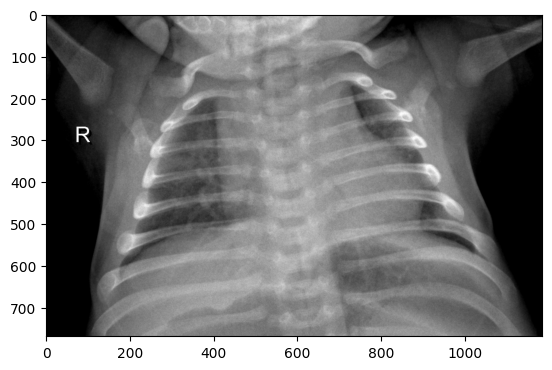

In [ ]:
rand_img_no = np.random.randint(0,len(files_list_normal_train))
img = os.path.join(actual_dataset_root, 'train', 'NORMAL', files_list_normal_train[rand_img_no])
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

(480, 912, 3)


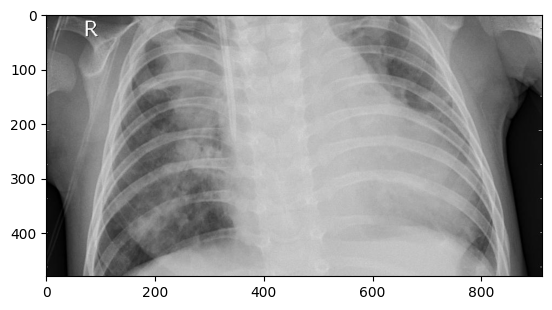

In [ ]:
img = os.path.join(actual_dataset_root, 'train', 'PNEUMONIA', files_list_pneumonia_train[np.random.randint(0,len(files_list_pneumonia_train))])
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

### Insights

- If we run the above cell mutiple times we can see that the images are of different shapes for the 'NORMAL' and 'PNEUMONIA' images in the **train** folder.

(1882, 2047, 3)


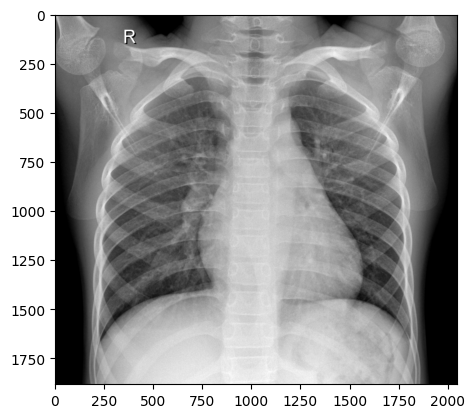

In [ ]:
rand_img_no = np.random.randint(0,len(files_list_normal_test))
img = os.path.join(actual_dataset_root, 'test', 'NORMAL', files_list_normal_test[rand_img_no])
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

(898, 1442, 3)


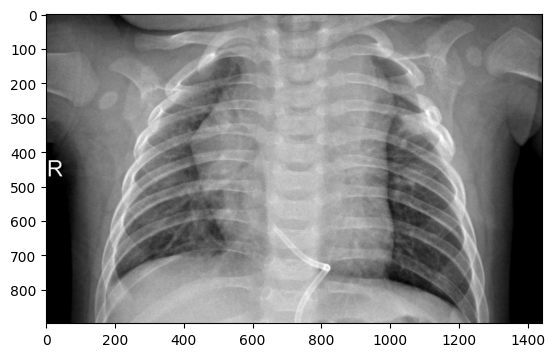

In [ ]:
img = os.path.join(actual_dataset_root, 'test', 'PNEUMONIA', files_list_pneumonia_test[np.random.randint(0,len(files_list_pneumonia_test))])
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)
plt.show()

### Insights

- If we run the above cell mutiple times we can see that the images are of different shapes for the 'NORMAL' and 'PNEUMONIA' images in the **test** folder.

### Transforming the Images

- Now that we have seen the sample of the images let's transform the data now
- We need to perform transformation on both train and test images
- For Training data we need to perform the data augmentation also.
- Data Augmentation is done to create synthetic data.

In **Transformation** we are doing Resize,CenterCrop,ColorJitter,RandomHorizontalFlip,RandomRotation,ToTensor and Normalize.

- Resize:- Resize the input image to the given size.
- CenterCrop:- Crops the given image at the center.
- ColorJitter:- Randomly change the brightness, contrast, saturation and hue of an image.
- RandomHorizontalFlip:- Horizontally flip the given image randomly with a given probability.
- RandomRotation:- Rotate the image by angle.
- ToTensor:- Convert numpy.ndarray to tensor.
- Normalize:- Normalize a float tensor image with mean and standard deviation.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ColorJitter(brightness=0.10, contrast=0.1, saturation=0.10, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225])
])


### Creating Data Loader

- For our usecase will be using the default data loader for Pytorch.
- We will be creating 2 data loaders one for the training data and other for the test data.
- batch size is a hyperparameter which we can tweak according to our need and system configuration.
- We can provide Image shuffling True for training data and False for test data.
- Pin memory is used to transfer the loaded dataset from CPU to GPU.

In [ ]:
import os
import kagglehub
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Re-defining data_path and actual_dataset_root for robustness against kernel state loss
data_path = kagglehub.dataset_download("prashant268/chest-xray-covid19-pneumonia")

actual_dataset_root = data_path # Start with the assumption that data_path is the root
dataset_contents = os.listdir(data_path)
subdirectories = [d for d in dataset_contents if os.path.isdir(os.path.join(data_path, d))]

if 'chest-xray-covid19-pneumonia' in subdirectories:
    actual_dataset_root = os.path.join(data_path, 'chest-xray-covid19-pneumonia')
elif len(subdirectories) == 1:
    actual_dataset_root = os.path.join(data_path, subdirectories[0])

# Re-defining transforms as they might also be undefined
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ColorJitter(brightness=0.10, contrast=0.1, saturation=0.10, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(os.path.join(actual_dataset_root, 'train'), transform= train_transform)
test_data = datasets.ImageFolder(os.path.join(actual_dataset_root, 'test'), transform= test_transform)
train_loader = DataLoader(train_data,
                          batch_size= 2, shuffle= True, pin_memory= True)
test_loader = DataLoader(test_data,
                         batch_size= 2, shuffle= False, pin_memory= True)
class_names = train_data.classes
print(class_names)
print(f'Number of train images: {len(train_data)}')
print(f'Number of test images: {len(test_data)}')

Using Colab cache for faster access to the 'chest-xray-covid19-pneumonia' dataset.
['COVID19', 'NORMAL', 'PNEUMONIA']
Number of train images: 5144
Number of test images: 1288


---
### Creating the model Architecture

- First Layer is the **input layer** consisting of 3 input channels and output channels with kernel_size of 3X3, padding=0 and bias=True. The activation function we are using is ReLU and performing batch normalization.
- Then we are performing max pooling to extract the important features out of the image.
- Similarly we are passing our model through 9 convolutional layers.
- Finally we are passing out passing our model through a output layer in which we are getting binary classification.


In [ ]:
class Net(nn.Module):
    def __init__(self):
        """
        Creating custom CNN architecture for Image classification
        """
        super(Net, self).__init__()
        # Input Block
        self.convolution_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=(3, 3),
                      padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(8)
        )
        self.pooling11 = nn.MaxPool2d(2, 2)
        # CONVOLUTION BLOCK 1
        self.convolution_block2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=20, kernel_size=(3, 3),
                      padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(20)
        )
        self.pooling22 = nn.MaxPool2d(2, 2)
        self.convolution_block3 = nn.Sequential(
            nn.Conv2d(in_channels=20, out_channels=10, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10),
        )
        self.pooling33 = nn.MaxPool2d(2, 2)
        # CONVOLUTION BLOCK 2
        self.convolution_block4 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=20, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(20)
        )
        self.convolution_block5 = nn.Sequential(
            nn.Conv2d(in_channels=20, out_channels=32, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(32),
        )
#         self.convblock6 = nn.Sequential(
#             nn.Conv2d(in_channels=32, out_channels=10, kernel_size=(1, 1), padding='same', bias=True),
#             nn.ReLU(),
#             nn.BatchNorm2d(10),
#         )
        self.convolution_block6 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=10, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
#         self.convblock8 = nn.Sequential(
#             nn.Conv2d(in_channels=10, out_channels=32, kernel_size=(1, 1), padding='same', bias=True),
#             nn.ReLU(),
#             nn.BatchNorm2d(32)
#         )
        self.convolution_block7 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        self.convolution_block8 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=14, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(14)
        )
        self.convolution_block9 = nn.Sequential(
            nn.Conv2d(in_channels=14, out_channels=16, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(16)
        )
        # OUTPUT BLOCK
        self.gap = nn.Sequential(
            nn.AvgPool2d(kernel_size=4)
        )
        # Changed out_channels to 3 for 3 classes (COVID19, NORMAL, PNEUMONIA)
        self.convolution_block_out = nn.Sequential(
              nn.Conv2d(in_channels=16, out_channels=3, kernel_size=(4, 4), padding=0, bias=True),
        )
    def forward(self, x):
        x = self.convolution_block1(x)
        x = self.pooling11(x)
        x = self.convolution_block2(x)
        x = self.pooling22(x)
        x = self.convolution_block3(x)
        x = self.pooling33(x)
        x = self.convolution_block4(x)
        x = self.convolution_block5(x)
#         x = self.convblock6(x)
        x = self.convolution_block6(x)
#         x = self.convblock8(x)
        x = self.convolution_block7(x)
        x = self.convolution_block8(x)
        x = self.convolution_block9(x)
        x = self.gap(x)
        x = self.convolution_block_out(x)
        # Changed reshape to 3 and activation to log_softmax for nll_loss
        x = x.view(-1, 3)   # reshape
        return F.log_softmax(x, dim=1)

In [ ]:
import numpy as np

In [ ]:
!pip show numpy

Name: numpy
Version: 2.4.3
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: accelerate, access, albucore, albumentations, ale-py, arviz, astropy, autograd, bigframes, blis, blosc2, bokeh, Bottleneck, bqplot, clarabel, cmdstanpy, contourpy, cufflinks, cvxpy, cyipopt, datasets, db-dtypes, diffusers, dm-tree, dopamine_rl, esda, flax, folium, geemap, geopandas, gradio, grain, gym, gymnasium, h5netcdf, h5py, hdbscan, highspy, holoviews, hyperopt, ImageIO, imbalanced-learn, inequality, jax, jaxlib, keras, keras-hub, libpysal, librosa, lightgbm, mapclassify, matplotlib, matplotlib-venn, mgwr, missingno, mizani, ml_dtypes, mlxtend, moviepy, music21, nibabel, numba, numexpr, opencv-contrib-python, opencv-python, opencv-python-headless, optax, orbax-checkpoint, osqp, pandas, pandas-gbq, pandas-stubs, patsy, peft, plotnine, poi

In [ ]:
# To check weather cuda is available in the system or not
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print("Available processor {}".format(device))
model = Net().to(device)
# To check the model summary
summary(model, input_size=(3, 224, 224))

Available processor cpu
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
              ReLU-2          [-1, 8, 222, 222]               0
       BatchNorm2d-3          [-1, 8, 222, 222]              16
         MaxPool2d-4          [-1, 8, 111, 111]               0
            Conv2d-5         [-1, 20, 109, 109]           1,460
              ReLU-6         [-1, 20, 109, 109]               0
       BatchNorm2d-7         [-1, 20, 109, 109]              40
         MaxPool2d-8           [-1, 20, 54, 54]               0
            Conv2d-9           [-1, 10, 54, 54]             210
             ReLU-10           [-1, 10, 54, 54]               0
      BatchNorm2d-11           [-1, 10, 54, 54]              20
        MaxPool2d-12           [-1, 10, 27, 27]               0
           Conv2d-13           [-1, 20, 25, 25]           1,820
             Re

# Downgrade numpy to a version compatible with PyTorch
!pip install numpy==1.23.5
print("NumPy downgraded. Please restart the Colab runtime (Runtime -> Restart runtime) then re-run all cells from the beginning.")
exit()

In [ ]:
train_losses = []
test_losses = []
train_acc = []
test_acc = []
def train(model, device, train_loader, optimizer, epoch):
    """
    Description: To train the model

    input: model,device,train_loader,optimizer,epoch

    output: loss, batch id and accuracy
    """
    model.train()
    pbar = tqdm(train_loader)
    correct = 0
    processed = 0
    for batch_idx, (data, target) in enumerate(pbar):
        # get data
        data, target = data.to(device), target.to(device)
        # Initialization of gradient
        optimizer.zero_grad()
        # In PyTorch, gradient is accumulated over backprop and even though thats used in RNN generally not used in CNN
        # or specific requirements
        ## prediction on data
        y_pred = model(data)
        # Calculating loss given the prediction
        loss = F.nll_loss(y_pred, target)
        train_losses.append(loss)
        # Backprop
        loss.backward()
        optimizer.step()
        # get the index of the log-probability corresponding to the max value
        pred = y_pred.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        processed += len(data)
        pbar.set_description(desc= f'Loss={loss.item()} Batch_id={batch_idx} Accuracy={100*correct/processed:0.2f}')
        train_acc.append(100*correct/processed)

def test(model, device, test_loader):
    """
    Description: To test the model

    input: model, device, test_loader

    output: average loss and accuracy

    """
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
            test_loss, correct, len(test_loader.dataset),
            100. * correct / len(test_loader.dataset)))
    test_acc.append(100. * correct / len(test_loader.dataset))

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import kagglehub

# To check weather cuda is available in the system or not
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print("Available processor {}".format(device))

class Net(nn.Module):
    def __init__(self):
        """
        Creating custom CNN architecture for Image classification
        """
        super(Net, self).__init__()
        # Input Block
        self.convolution_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=(3, 3),
                      padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(8)
        )
        self.pooling11 = nn.MaxPool2d(2, 2)
        # CONVOLUTION BLOCK 1
        self.convolution_block2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=20, kernel_size=(3, 3),
                      padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(20)
        )
        self.pooling22 = nn.MaxPool2d(2, 2)
        self.convolution_block3 = nn.Sequential(
            nn.Conv2d(in_channels=20, out_channels=10, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10),
        )
        self.pooling33 = nn.MaxPool2d(2, 2)
        # CONVOLUTION BLOCK 2
        self.convolution_block4 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=20, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(20)
        )
        self.convolution_block5 = nn.Sequential(
            nn.Conv2d(in_channels=20, out_channels=32, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(32),
        )
#         self.convblock6 = nn.Sequential(
#             nn.Conv2d(in_channels=32, out_channels=10, kernel_size=(1, 1), padding='same', bias=True),
#             nn.ReLU(),
#             nn.BatchNorm2d(10),
#         )
        self.convolution_block6 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=10, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
#         self.convblock8 = nn.Sequential(
#             nn.Conv2d(in_channels=10, out_channels=32, kernel_size=(1, 1), padding='same', bias=True),
#             nn.ReLU(),
#             nn.BatchNorm2d(32)
#         )
        self.convolution_block7 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=(1, 1), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(10)
        )
        self.convolution_block8 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=14, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(14)
        )
        self.convolution_block9 = nn.Sequential(
            nn.Conv2d(in_channels=14, out_channels=16, kernel_size=(3, 3), padding=0, bias=True),
            nn.ReLU(),
            nn.BatchNorm2d(16)
        )
        # OUTPUT BLOCK
        self.gap = nn.Sequential(
            nn.AvgPool2d(kernel_size=4)
        )
        # Changed out_channels to 3 for 3 classes (COVID19, NORMAL, PNEUMONIA)
        self.convolution_block_out = nn.Sequential(
              nn.Conv2d(in_channels=16, out_channels=3, kernel_size=(4, 4), padding=0, bias=True),
        )
    def forward(self, x):
        x = self.convolution_block1(x)
        x = self.pooling11(x)
        x = self.convolution_block2(x)
        x = self.pooling22(x)
        x = self.convolution_block3(x)
        x = self.pooling33(x)
        x = self.convolution_block4(x)
        x = self.convolution_block5(x)
#         x = self.convblock6(x)
        x = self.convolution_block6(x)
#         x = self.convblock8(x)
        x = self.convolution_block7(x)
        x = self.convolution_block8(x)
        x = self.convolution_block9(x)
        x = self.gap(x)
        x = self.convolution_block_out(x)
        # Changed reshape to 3 and activation to log_softmax for nll_loss
        x = x.view(-1, 3)   # reshape
        return F.log_softmax(x, dim=1)

train_losses = []
test_losses = []
train_acc = []
test_acc = []
def train(model, device, train_loader, optimizer, epoch):
    """
    Description: To train the model

    input: model,device,train_loader,optimizer,epoch

    output: loss, batch id and accuracy
    """
    model.train()
    pbar = tqdm(train_loader)
    correct = 0
    processed = 0
    for batch_idx, (data, target) in enumerate(pbar):
        # get data
        data, target = data.to(device), target.to(device)
        # Initialization of gradient
        optimizer.zero_grad()
        # In PyTorch, gradient is accumulated over backprop and even though thats used in RNN generally not used in CNN
        # or specific requirements
        ## prediction on data
        y_pred = model(data)
        # Calculating loss given the prediction
        loss = F.nll_loss(y_pred, target)
        train_losses.append(loss)
        # Backprop
        loss.backward()
        optimizer.step()
        # get the index of the log-probability corresponding to the max value
        pred = y_pred.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        processed += len(data)
        pbar.set_description(desc= f'Loss={loss.item()} Batch_id={batch_idx} Accuracy={100*correct/processed:0.2f}')
        train_acc.append(100*correct/processed)

def test(model, device, test_loader):
    """
    Description: To test the model

    input: model, device, test_loader

    output: average loss and accuracy

    """
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
            test_loss, correct, len(test_loader.dataset),
            100. * correct / len(test_loader.dataset)))
    test_acc.append(100. * correct / len(test_loader.dataset))

# --- Start of Data Loader Creation ---
# Re-defining data_path and actual_dataset_root for robustness against kernel state loss
data_path = kagglehub.dataset_download("prashant268/chest-xray-covid19-pneumonia")

actual_dataset_root = data_path # Start with the assumption that data_path is the root
dataset_contents = os.listdir(data_path)
subdirectories = [d for d in dataset_contents if os.path.isdir(os.path.join(data_path, d))]

if 'chest-xray-covid19-pneumonia' in subdirectories:
    actual_dataset_root = os.path.join(data_path, 'chest-xray-covid19-pneumonia')
elif len(subdirectories) == 1:
    # If there's only one subdirectory, assume it's the dataset's main folder
    actual_dataset_root = os.path.join(data_path, subdirectories[0])

# Re-defining transforms as they might also be undefined
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ColorJitter(brightness=0.10, contrast=0.1, saturation=0.10, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                          [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(os.path.join(actual_dataset_root, 'train'), transform= train_transform)
test_data = datasets.ImageFolder(os.path.join(actual_dataset_root, 'test'), transform= test_transform)
train_loader = DataLoader(train_data,
                          batch_size= 2, shuffle= True, pin_memory= True)
test_loader = DataLoader(test_data,
                         batch_size= 2, shuffle= False, pin_memory= True)
class_names = train_data.classes
print(class_names)
print(f'Number of train images: {len(train_data)}')
print(f'Number of test images: {len(test_data)}')
# --- End of Data Loader Creation ---


# Defining the params for training
model =  Net().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.8)
scheduler = StepLR(optimizer, step_size=6, gamma=0.5)
EPOCHS = 4

checkpoint_path = "model_checkpoint.pth"
start_epoch = 0

# Check if a checkpoint exists and load it
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    # Restore training metrics
    global train_losses, test_losses, train_acc, test_acc
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']
    train_acc = checkpoint['train_acc']
    test_acc = checkpoint['test_acc']
    print(f"Resuming training from epoch {start_epoch}")
else:
    print("No checkpoint found, starting training from scratch.")

# Training the model
for epoch in range(start_epoch, EPOCHS):
    print("EPOCH:", epoch)
    train(model, device, train_loader, optimizer, epoch)
    scheduler.step()
    print('current Learning Rate: ', optimizer.state_dict()["param_groups"][0]["lr"])
    test(model, device, test_loader)

    # Save checkpoint after each epoch
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_acc': train_acc,
        'test_acc': test_acc,
    }, checkpoint_path)
    print(f"Checkpoint saved for epoch {epoch} at {checkpoint_path}")

Available processor cpu
Using Colab cache for faster access to the 'chest-xray-covid19-pneumonia' dataset.
['COVID19', 'NORMAL', 'PNEUMONIA']
Number of train images: 5144
Number of test images: 1288
No checkpoint found, starting training from scratch.
EPOCH: 0


  0%|          | 0/2572 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Loss=2.557762622833252 Batch_id=2571 Accuracy=83.90: 100%|██████████| 2572/2572 [05:31<00:00,  7.75it/s]


current Learning Rate:  0.01

Test set: Average loss: 0.2875, Accuracy: 1149/1288 (89.21%)

Checkpoint saved for epoch 0 at model_checkpoint.pth
EPOCH: 1


Loss=0.7389252185821533 Batch_id=2571 Accuracy=88.12: 100%|██████████| 2572/2572 [04:46<00:00,  8.97it/s]


current Learning Rate:  0.01

Test set: Average loss: 0.2748, Accuracy: 1164/1288 (90.37%)

Checkpoint saved for epoch 1 at model_checkpoint.pth
EPOCH: 2


Loss=0.027913693338632584 Batch_id=2054 Accuracy=88.81:  80%|███████▉  | 2055/2572 [03:54<00:52,  9.79it/s]

### Evaluate the Model

- Plotting the graph for taining loss and training accuracy
- Plotting the graph for test loss and test accuracy

Text(0.5, 1.0, 'Test Accuracy')

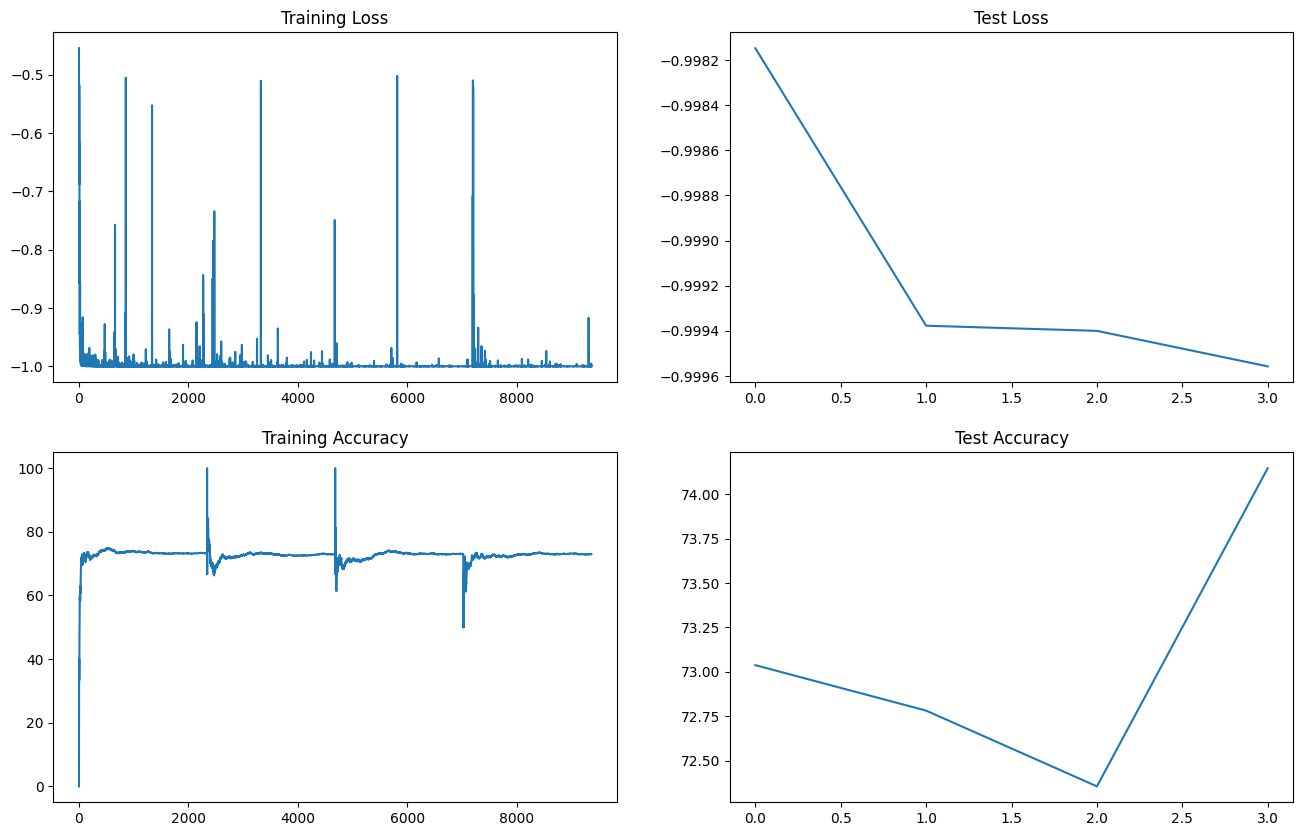

In [ ]:
train_losses1 = [float(i.cpu().detach().numpy()) for i in train_losses]
train_acc1 = [i for i in train_acc]
test_losses1 = [i for i in test_losses]
test_acc1 = [i for i in test_acc]
fig, axs = plt.subplots(2,2,figsize=(16,10))
axs[0, 0].plot(train_losses1)
axs[0, 0].set_title("Training Loss")
axs[1, 0].plot(train_acc1)
axs[1, 0].set_title("Training Accuracy")
axs[0, 1].plot(test_losses1)
axs[0, 1].set_title("Test Loss")
axs[1, 1].plot(test_acc1)
axs[1, 1].set_title("Test Accuracy")


### Insights

- As we can see from the above graph that training loss has many fluctuation at the start but then it consolidates over a period of time.
- From the training accuracy graph we are able to get a training accuracy of around 50% throughout
- Test loss graph decreases as the number of epochs increases.
- test accuracy remains constant at around 50%.

In [ ]:
torch.save(model.state_dict(), "xray_model.pth")